# EEG-Based Age Classification — Dortmund Vital Study Resting-State EEG
## Notebook 03: Spectral Feature Extraction

**Dataset:** DS005385 — Resting-state EEG data before and after cognitive activity across the adult lifespan
**Depends on:** `02_preprocessing.ipynb` (produces per-subject preprocessed epoch files and `preprocessing_log.csv`)

### Purpose
This notebook converts each subject's cleaned, epoched EEG into a compact set of spectral features: the relative power of the delta, theta, alpha, beta and gamma frequency bands at every electrode, plus the individual alpha peak frequency. The resulting feature matrix is the dataset used to train the classifier in Notebook 04. Before any modeling, the features are compared between age groups to confirm they carry age-related information.

### Pipeline overview
1. Apply a data-quality threshold: exclude subjects with too few artifact-free epochs.
2. Estimate each subject's power spectral density (PSD) with Welch's method.
3. Divide the spectrum into five non-overlapping frequency bands.
4. Compute relative band power for every channel.
5. Estimate the individual alpha peak frequency from posterior electrodes.
6. Apply the pipeline to the full cohort and save the feature matrix.
7. Compare spectra and features between the young and old groups.

## Execution Environment: Google Colab (via VS Code)

This notebook's kernel is a remote Colab VM, connected through the Google Colab extension for VS Code. It reads the preprocessed epoch files and the preprocessing log written by Notebook 02 to `/content/data`. Colab virtual machines are temporary, so if those files are missing, Notebooks 00, 01 and 02 must be run on the current runtime first. Step 1 checks for this and stops with a clear message.

In [1]:
"""
Colab remote-kernel setup. Installs MNE-Python at the pinned project
version, imports the libraries used throughout this notebook, defines
shared paths, and limits MNE's console output to warnings so that loops
over the full cohort produce readable output.
"""

!pip install -q mne==1.13.2

import os

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import mne

mne.set_log_level("WARNING")

DATA_DIR = "/content/data"
FIGURES_DIR = "/content/figures"
PREPROCESSED_DIR = f"{DATA_DIR}/preprocessed"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Data directory        :", DATA_DIR)
print("Preprocessed directory:", PREPROCESSED_DIR)
print("Figures directory     :", FIGURES_DIR)
print("MNE version           :", mne.__version__)

Data directory        : /content/data
Preprocessed directory: /content/data/preprocessed
Figures directory     : /content/figures
MNE version           : 1.13.2


## Step 1 — Load the Cohort and Apply a Data-Quality Threshold

Notebook 02 recorded how many 4-second epochs survived artifact rejection for every subject. A power spectrum estimated from very little clean data is unreliable, because Welch's method reduces noise by averaging many windows. Subjects with fewer than **10 surviving epochs (40 seconds of clean data)** are therefore excluded. This is the same threshold Notebook 02 used to flag low-quality recordings, so the exclusion rule is defined once, applied before any features are computed, and reported transparently, including its effect on the balance between age groups.

In [2]:
"""
Load the labeled cohort and Notebook 02's preprocessing log, then keep
only subjects whose preprocessed epoch file exists and contains at
least MIN_EPOCHS_REQUIRED epochs.
"""

MIN_EPOCHS_REQUIRED = 10

cohort_path = f"{DATA_DIR}/cohort_labels.csv"
log_path = f"{DATA_DIR}/preprocessing_log.csv"
for required in (cohort_path, log_path):
    if not os.path.exists(required):
        raise FileNotFoundError(f"{required} not found. Run Notebooks 00-02 on this runtime first.")

cohort = pd.read_csv(cohort_path, dtype={"subject": str})
preprocessing_log = pd.read_csv(log_path, dtype={"subject": str})
cohort = cohort.merge(preprocessing_log, on="subject", how="left")

cohort["epo_path"] = PREPROCESSED_DIR + "/sub-" + cohort["subject"] + "-epo.fif"
cohort["file_present"] = cohort["epo_path"].map(os.path.exists)
passes_qc = cohort["file_present"] & (cohort["n_epochs_kept"] >= MIN_EPOCHS_REQUIRED)

excluded = cohort.loc[~passes_qc, ["subject", "age_group", "n_epochs_kept", "file_present"]]
analysis_cohort = cohort.loc[passes_qc].reset_index(drop=True)

print(f"Subjects in labeled cohort      : {len(cohort)}")
print(f"Excluded (< {MIN_EPOCHS_REQUIRED} epochs or missing): {len(excluded)}")
print(f"Retained for feature extraction : {len(analysis_cohort)}")
print("\nRetained subjects per group:")
print(analysis_cohort["age_group"].value_counts())
print("\nExcluded subjects:")
print(excluded.to_string(index=False))

Subjects in labeled cohort      : 416
Excluded (< 10 epochs or missing): 11
Retained for feature extraction : 405

Retained subjects per group:
age_group
old      209
young    196
Name: count, dtype: int64

Excluded subjects:
subject age_group  n_epochs_kept  file_present
    025     young              8          True
    079     young              0          True
    104       old              2          True
    112       old              4          True
    115       old              1          True
    185     young              2          True
    192     young              7          True
    205       old              5          True
    230     young              2          True
    353     young              4          True
    381     young              9          True


## Step 2 — Load One Example Subject's Epochs

As in previous notebooks, each step is developed and checked on one subject before being applied to the full cohort.

In [3]:
"""
Load the preprocessed epochs of one example subject.
"""

example_row = analysis_cohort.iloc[0]
example_subject = example_row["subject"]
example_epochs = mne.read_epochs(example_row["epo_path"], preload=True)

print(f"Example subject: {example_subject} ({example_row['age_group']}, age {example_row['age']})")
print(example_epochs)

Example subject: 001 (old, age 60)
<EpochsFIF | 34 events (all good), 0 – 3.996 s (baseline off), ~16.7 MiB, data loaded,
 '1': 34>


## Step 3 — Estimate the Power Spectral Density with Welch's Method

Welch's method splits the signal into short, overlapping windows, computes a Fourier-transform-based spectrum for each window, and averages the results. This gives a much more stable estimate than a single transform of the whole signal. Each 4-second epoch is split into 2-second windows (`n_fft = 500` samples at 250 Hz) overlapping by 50%, giving three windows per epoch; the spectra of all windows across all epochs are then averaged for each channel.

The window length sets the **frequency resolution**: a 2-second window resolves frequencies in steps of 1 / 2 s = 0.5 Hz. This places several frequency bins inside even the narrowest band used here (delta, 1-4 Hz) while still averaging enough windows to keep the estimate stable. The parameters are fixed explicitly, rather than left to library defaults, so the analysis is fully reproducible.

PSD array shape      : (34, 64, 89)  (epochs, channels, frequencies)
Frequency resolution : 0.50 Hz
Frequency range      : 1.0-45.0 Hz (89 bins)


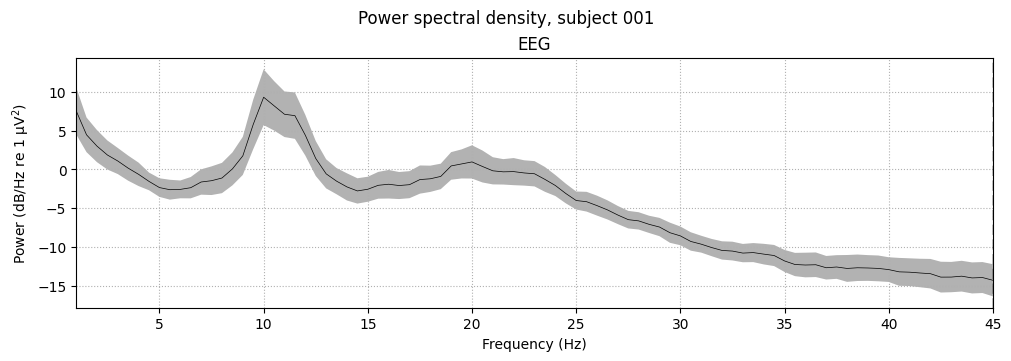

In [4]:
"""
Compute the PSD of every epoch of the example subject with Welch's
method, restricted to 1-45 Hz (the band-pass range applied in
Notebook 02), and plot the spectrum averaged over epochs and channels.
"""

WELCH_PARAMS = dict(method="welch", fmin=1.0, fmax=45.0, n_fft=500, n_overlap=250)

example_psd = example_epochs.compute_psd(**WELCH_PARAMS)
psd_data, freqs = example_psd.get_data(return_freqs=True)

print(f"PSD array shape      : {psd_data.shape}  (epochs, channels, frequencies)")
print(f"Frequency resolution : {freqs[1] - freqs[0]:.2f} Hz")
print(f"Frequency range      : {freqs[0]:.1f}-{freqs[-1]:.1f} Hz ({len(freqs)} bins)")

fig = example_psd.plot(average=True, amplitude=False, show=False)
fig.suptitle(f"Power spectral density, subject {example_subject}")
fig.savefig(f"{FIGURES_DIR}/03_example_psd.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Define Non-Overlapping Frequency Bands

The five classic EEG frequency bands are defined below. Each band includes its lower edge and excludes its upper edge (for example, alpha covers 8 Hz up to, but not including, 13 Hz), except the highest band, which also includes 45 Hz. Every frequency bin between 1 and 45 Hz therefore belongs to exactly one band: no power is counted twice at a shared boundary, and none is left out.

In [5]:
"""
Define the frequency bands and a helper that assigns every frequency
bin to exactly one band, then confirm complete, non-overlapping coverage.
"""

FREQUENCY_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}


def make_band_masks(freqs, bands=FREQUENCY_BANDS):
    """Return {band: boolean mask over freqs}. Bands span [low, high),
    except the highest band, which also includes its upper edge."""
    top_edge = max(high for _, high in bands.values())
    masks = {}
    for name, (low, high) in bands.items():
        below_upper = (freqs <= high) if high == top_edge else (freqs < high)
        masks[name] = (freqs >= low) & below_upper
    return masks


band_masks = make_band_masks(freqs)

for name, mask in band_masks.items():
    low, high = FREQUENCY_BANDS[name]
    print(f"{name:6s}: {low:4.1f}-{high:4.1f} Hz  ->  {mask.sum():2d} frequency bins")

coverage = np.sum(list(band_masks.values()), axis=0)
assert np.all(coverage == 1), "Every frequency bin must belong to exactly one band."
print("\nEvery frequency bin is assigned to exactly one band.")

delta :  1.0- 4.0 Hz  ->   6 frequency bins
theta :  4.0- 8.0 Hz  ->   8 frequency bins
alpha :  8.0-13.0 Hz  ->  10 frequency bins
beta  : 13.0-30.0 Hz  ->  34 frequency bins
gamma : 30.0-45.0 Hz  ->  31 frequency bins

Every frequency bin is assigned to exactly one band.


## Step 5 — Compute Relative Band Power

The PSD gives power per hertz at each frequency bin. Multiplying each bin's value by the bin width (0.5 Hz) and summing the bins inside a band gives that band's **absolute power**. Each band's power is then divided by the channel's total power across 1-45 Hz to give **relative power**: the share of the signal's energy carried by that band.

Relative power is used because absolute power also depends on factors unrelated to brain rhythms, such as electrode contact quality and skull thickness, which scale every band up or down together. Relative power removes this overall scale and keeps the balance between rhythms, which is what changes with age. Because the bands cover the spectrum exactly once, the five relative powers of every channel sum to exactly 1.

In [6]:
"""
Compute absolute and relative band power for the example subject.
"""

mean_psd = psd_data.mean(axis=0)        # average over epochs: (channels, freqs)
bin_width = freqs[1] - freqs[0]         # 0.5 Hz

absolute_power = pd.DataFrame(
    {band: mean_psd[:, mask].sum(axis=-1) * bin_width for band, mask in band_masks.items()},
    index=example_epochs.ch_names,
)
total_power = mean_psd.sum(axis=-1) * bin_width
relative_power = absolute_power.div(total_power, axis=0)

band_sums = relative_power.sum(axis=1)
print("Relative power summed across bands (should be exactly 1 for every channel):")
print(f"  min = {band_sums.min():.6f}, max = {band_sums.max():.6f}")

relative_power.round(3).head(10)

Relative power summed across bands (should be exactly 1 for every channel):
  min = 1.000000, max = 1.000000


,delta,theta,alpha,beta,gamma
Fp1,0.537,0.051,0.244,0.140,0.029
Fp2,0.633,0.054,0.187,0.107,0.019
F7,0.481,0.054,0.303,0.138,0.023
F3,0.166,0.067,0.395,0.319,0.053
Fz,0.190,0.078,0.402,0.307,0.024
F4,0.203,0.072,0.359,0.325,0.040
F8,0.293,0.083,0.363,0.228,0.032
FC5,0.166,0.071,0.420,0.313,0.030
FC1,0.175,0.083,0.395,0.324,0.023
FC2,0.173,0.081,0.391,0.330,0.026


## Step 6 — Estimate the Individual Alpha Peak Frequency

Beyond how much alpha power a person has, the frequency at which their alpha rhythm peaks is itself informative: alpha frequency rises from childhood to adulthood and declines in later life (Klimesch, 1999). It is estimated here as the frequency of maximum power between 7 and 13 Hz in the average spectrum of posterior electrodes (parietal, parieto-occipital and occipital), where eyes-closed alpha is strongest. With 0.5 Hz frequency resolution, the estimate is reported in 0.5 Hz steps.

*Reference:* Klimesch, W. (1999). EEG alpha and theta oscillations reflect cognitive and memory performance: a review and analysis. *Brain Research Reviews*, 29, 169-195. https://doi.org/10.1016/S0165-0173(98)00056-3

Individual alpha peak frequency (subject 001): 10.0 Hz


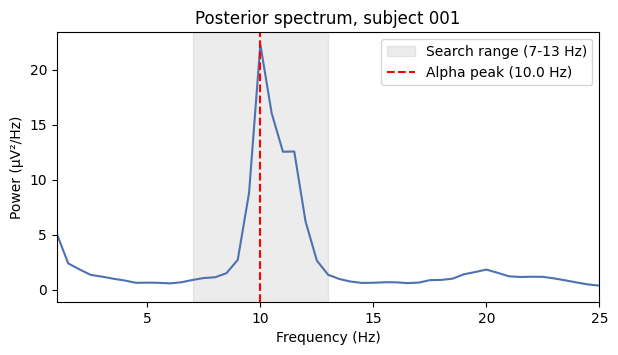

In [7]:
"""
Estimate the individual alpha peak frequency (IAF) from the mean PSD of
posterior electrodes, and plot it for the example subject.
"""

POSTERIOR_CHANNELS = ["P3", "Pz", "P4", "PO3", "POz", "PO4", "O1", "Oz", "O2"]
IAF_SEARCH_RANGE = (7.0, 13.0)


def estimate_iaf(mean_psd, freqs, ch_names,
                 posterior_channels=POSTERIOR_CHANNELS, search_range=IAF_SEARCH_RANGE):
    """Return the frequency (Hz) of maximum posterior power within search_range."""
    idx = [ch_names.index(ch) for ch in posterior_channels if ch in ch_names]
    posterior_psd = mean_psd[idx].mean(axis=0)
    in_range = (freqs >= search_range[0]) & (freqs <= search_range[1])
    return float(freqs[in_range][np.argmax(posterior_psd[in_range])])


example_iaf = estimate_iaf(mean_psd, freqs, example_epochs.ch_names)
print(f"Individual alpha peak frequency (subject {example_subject}): {example_iaf:.1f} Hz")

posterior_idx = [example_epochs.ch_names.index(ch) for ch in POSTERIOR_CHANNELS
                 if ch in example_epochs.ch_names]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(freqs, mean_psd[posterior_idx].mean(axis=0) * 1e12, color="#4C72B0")  # V²/Hz to µV²/Hz
ax.axvspan(*IAF_SEARCH_RANGE, color="grey", alpha=0.15, label="Search range (7-13 Hz)")
ax.axvline(example_iaf, color="red", linestyle="--", label=f"Alpha peak ({example_iaf:.1f} Hz)")
ax.set_xlim(1, 25)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (µV²/Hz)")
ax.set_title(f"Posterior spectrum, subject {example_subject}")
ax.legend()
fig.savefig(f"{FIGURES_DIR}/03_example_alpha_peak.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 7 — Visualize the Spatial Distribution of Each Band

Relative power of each band is mapped across the scalp for the example subject. During eyes-closed rest, alpha power is expected to be strongest over posterior electrodes, a well-established pattern that serves as a visual check on the pipeline before scaling up. Each map has its own color scale, since the bands differ greatly in their share of total power.

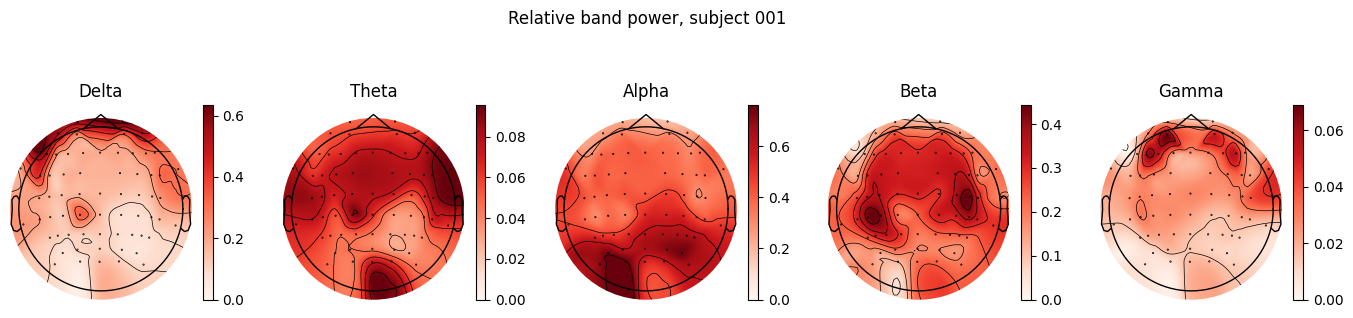

In [8]:
"""
Plot scalp maps of relative power for each frequency band for the
example subject.
"""

fig, axes = plt.subplots(1, len(FREQUENCY_BANDS), figsize=(17, 3.6))
for ax, band in zip(axes, FREQUENCY_BANDS):
    im, _ = mne.viz.plot_topomap(relative_power[band].values, example_epochs.info,
                                 axes=ax, show=False)
    ax.set_title(band.capitalize())
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle(f"Relative band power, subject {example_subject}", y=1.03)
fig.savefig(f"{FIGURES_DIR}/03_example_band_topomaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Consolidate into a Reusable Function

With every step validated on the example subject, the pipeline is wrapped into a single function, and its output is checked against the step-by-step result above before being applied to the full cohort.

In [9]:
"""
The full feature-extraction pipeline as a single reusable function,
verified against the step-by-step computation above.
"""

def extract_spectral_features(epochs, bands=FREQUENCY_BANDS, welch_params=WELCH_PARAMS):
    """Compute one subject's spectral features.

    Returns
    -------
    features : dict
        {"{channel}_{band}": relative power} for every channel and band,
        plus "iaf" (individual alpha peak frequency, Hz).
    channel_mean_psd : np.ndarray
        Spectrum averaged over epochs and channels (V²/Hz), kept for
        group-level visualization.
    freqs : np.ndarray
        Frequencies of the spectrum (Hz).
    """
    psd = epochs.compute_psd(**welch_params)
    psd_data, freqs = psd.get_data(return_freqs=True)
    mean_psd = psd_data.mean(axis=0)
    bin_width = freqs[1] - freqs[0]
    total_power = mean_psd.sum(axis=-1) * bin_width

    features = {}
    for band, mask in make_band_masks(freqs, bands).items():
        relative = mean_psd[:, mask].sum(axis=-1) * bin_width / total_power
        for ch, value in zip(epochs.ch_names, relative):
            features[f"{ch}_{band}"] = float(value)
    features["iaf"] = estimate_iaf(mean_psd, freqs, epochs.ch_names)

    return features, mean_psd.mean(axis=0), freqs


check_features, _, _ = extract_spectral_features(example_epochs)
manual = {f"{ch}_{band}": relative_power.loc[ch, band]
          for band in FREQUENCY_BANDS for ch in example_epochs.ch_names}
max_difference = max(abs(check_features[key] - value) for key, value in manual.items())

print(f"Features per subject: {len(check_features)} "
      f"({len(example_epochs.ch_names)} channels x {len(FREQUENCY_BANDS)} bands + IAF)")
print(f"Largest difference from the step-by-step result: {max_difference:.2e}")
print(f"IAF matches step-by-step result: {check_features['iaf'] == example_iaf}")

Features per subject: 321 (64 channels x 5 bands + IAF)
Largest difference from the step-by-step result: 0.00e+00
IAF matches step-by-step result: True


## Step 9 — Apply the Pipeline to the Full Cohort

The validated function is applied to every subject that passed the quality threshold in Step 1. Each subject's channel-averaged spectrum is also kept for the group comparisons later in this notebook. Failures are collected rather than halting the run.

In [10]:
"""
Extract spectral features for every retained subject.
"""

feature_rows, group_spectra, failed_subjects = [], [], []
total = len(analysis_cohort)

for i, row in enumerate(analysis_cohort.itertuples(), start=1):
    try:
        subject_epochs = mne.read_epochs(row.epo_path, preload=True)
        features, spectrum, spectrum_freqs = extract_spectral_features(subject_epochs)
        feature_rows.append({"subject": row.subject, "age_group": row.age_group, **features})
        group_spectra.append({"age_group": row.age_group, "spectrum": spectrum})
    except Exception as e:
        failed_subjects.append(row.subject)
        print(f"[{i}/{total}] FAILED - subject {row.subject}: {e}")

    if i % 25 == 0 or i == total:
        print(f"[{i}/{total}] processed, {len(failed_subjects)} failure(s) so far")

print(f"\nFeature vectors extracted: {len(feature_rows)} / {total}")

[25/405] processed, 0 failure(s) so far
[50/405] processed, 0 failure(s) so far
[75/405] processed, 0 failure(s) so far
[100/405] processed, 0 failure(s) so far
[125/405] processed, 0 failure(s) so far
[150/405] processed, 0 failure(s) so far
[175/405] processed, 0 failure(s) so far
[200/405] processed, 0 failure(s) so far
[225/405] processed, 0 failure(s) so far
[250/405] processed, 0 failure(s) so far
[275/405] processed, 0 failure(s) so far
[300/405] processed, 0 failure(s) so far
[325/405] processed, 0 failure(s) so far
[350/405] processed, 0 failure(s) so far
[375/405] processed, 0 failure(s) so far
[400/405] processed, 0 failure(s) so far
[405/405] processed, 0 failure(s) so far

Feature vectors extracted: 405 / 405


## Step 10 — Assemble and Persist the Feature Matrix

The feature matrix has one row per subject: the subject ID, the age-group label, and the spectral features. Subject age is deliberately **not** included. A column holding age would let a classifier read the answer directly, a form of data leakage, so the label is the only age-related column in the file. Two checks are reported: missing values, and how many subjects had their alpha peak at the edge of the 7-13 Hz search range, which indicates no clear alpha peak.

In [11]:
"""
Assemble the feature matrix, run basic integrity checks, and save it.
"""

features_df = pd.DataFrame(feature_rows)
feature_cols = [c for c in features_df.columns if c not in ("subject", "age_group")]

n_missing = int(features_df[feature_cols].isna().sum().sum())
n_iaf_at_edge = int(features_df["iaf"].isin(IAF_SEARCH_RANGE).sum())

print(f"Feature matrix shape: {features_df.shape} "
      f"({len(features_df)} subjects x {len(feature_cols)} features + subject + label)")
print(f"Missing values      : {n_missing}")
print(f"IAF at edge of 7-13 Hz search range (no clear alpha peak): {n_iaf_at_edge}")
print("\nSubjects per group:")
print(features_df["age_group"].value_counts())

features_path = f"{DATA_DIR}/spectral_features.csv"
features_df.to_csv(features_path, index=False)
print(f"\nSaved feature matrix to {features_path}")

features_df.iloc[:5, :8]

Feature matrix shape: (405, 323) (405 subjects x 321 features + subject + label)
Missing values      : 0
IAF at edge of 7-13 Hz search range (no clear alpha peak): 15

Subjects per group:
age_group
old      209
young    196
Name: count, dtype: int64

Saved feature matrix to /content/data/spectral_features.csv


,subject,age_group,Fp1_delta,Fp2_delta,F7_delta,F3_delta,Fz_delta,F4_delta
0,001,old,0.536516,0.632924,0.481151,0.165831,0.189657,0.203235
1,002,old,0.747595,0.698378,0.486434,0.300286,0.353206,0.332806
2,004,young,0.635422,0.615883,0.275586,0.147615,0.271576,0.196501
3,006,old,0.519891,0.586795,0.649441,0.340645,0.215689,0.268852
4,007,young,0.663910,0.701876,0.541864,0.456191,0.441688,0.463402


## Step 11 — Compare Group-Average Spectra

The average spectrum of each age group is plotted, with shading showing the standard error of the mean. Dotted lines mark the band boundaries. Because these spectra are in absolute units, an overall vertical offset between groups can partly reflect non-neural factors such as skull thickness. Differences in *shape*, such as the position of the alpha peak or the relative height of slow and fast activity, are more directly interpretable.

The comparisons in Steps 11-13 are descriptive. They use the whole cohort and are not used to choose features, since doing so would leak information about test subjects into the model's design. Whether these features predict age group for unseen subjects is tested in Notebook 04 with cross-validation.

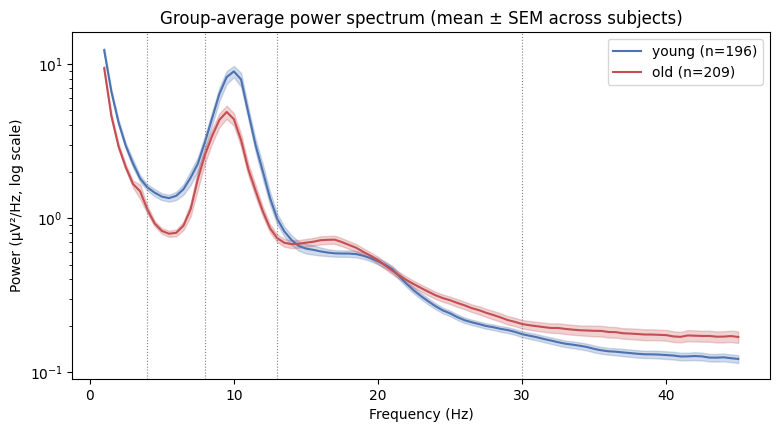

In [12]:
"""
Plot the mean spectrum (averaged over channels) of each age group, with
standard-error shading.
"""

GROUPS = ["young", "old"]
GROUP_COLORS = {"young": "#4C72B0", "old": "#C44E52"}

spectra = np.vstack([s["spectrum"] for s in group_spectra]) * 1e12   # V²/Hz to µV²/Hz
spectrum_groups = np.array([s["age_group"] for s in group_spectra])

fig, ax = plt.subplots(figsize=(9, 4.5))
for group in GROUPS:
    data = spectra[spectrum_groups == group]
    mean = data.mean(axis=0)
    sem = data.std(axis=0, ddof=1) / np.sqrt(len(data))
    ax.plot(spectrum_freqs, mean, color=GROUP_COLORS[group], label=f"{group} (n={len(data)})")
    ax.fill_between(spectrum_freqs, mean - sem, mean + sem, color=GROUP_COLORS[group], alpha=0.25)

for low, _ in list(FREQUENCY_BANDS.values())[1:]:
    ax.axvline(low, color="grey", linestyle=":", linewidth=0.8)

ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (µV²/Hz, log scale)")
ax.set_title("Group-average power spectrum (mean ± SEM across subjects)")
ax.legend()
fig.savefig(f"{FIGURES_DIR}/03_group_spectra.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 12 — Compare Band Power and Alpha Peak Frequency Between Groups

For each band, every subject's relative power is averaged over all 64 channels and shown as a box plot per group, alongside the individual alpha peak frequency. Group medians are printed below the figure.

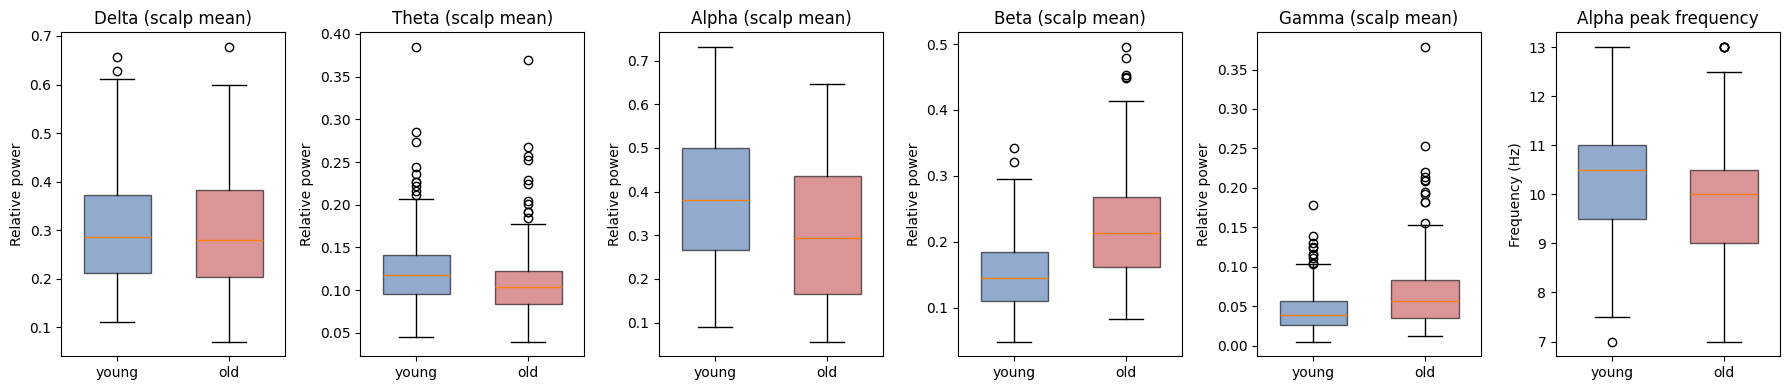

Group medians:
        young     old
delta   0.286   0.279
theta   0.118   0.104
alpha   0.380   0.293
beta    0.145   0.214
gamma   0.039   0.057
iaf    10.500  10.000


In [13]:
"""
Box plots of whole-scalp relative band power and individual alpha peak
frequency, by age group, with a table of group medians.
"""

panels = list(FREQUENCY_BANDS) + ["iaf"]
medians = {}

fig, axes = plt.subplots(1, len(panels), figsize=(18, 4))
for ax, panel in zip(axes, panels):
    if panel == "iaf":
        values = features_df["iaf"]
        title, ylabel = "Alpha peak frequency", "Frequency (Hz)"
    else:
        columns = [f"{ch}_{panel}" for ch in example_epochs.ch_names]
        values = features_df[columns].mean(axis=1)
        title, ylabel = f"{panel.capitalize()} (scalp mean)", "Relative power"

    data = [values[features_df["age_group"] == g] for g in GROUPS]
    boxes = ax.boxplot(data, tick_labels=GROUPS, patch_artist=True, widths=0.6)
    for patch, group in zip(boxes["boxes"], GROUPS):
        patch.set_facecolor(GROUP_COLORS[group])
        patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    medians[panel] = {g: values[features_df["age_group"] == g].median() for g in GROUPS}

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/03_group_band_power.png", dpi=150, bbox_inches="tight")
plt.show()

print("Group medians:")
print(pd.DataFrame(medians).T.round(3))

## Step 13 — Map Where on the Scalp the Groups Differ

For each band, the mean relative power of the young group is subtracted from that of the old group at every electrode. Red indicates higher relative power in older adults, blue higher in younger adults. Each map uses a symmetric color scale centred on zero, so white means no difference.

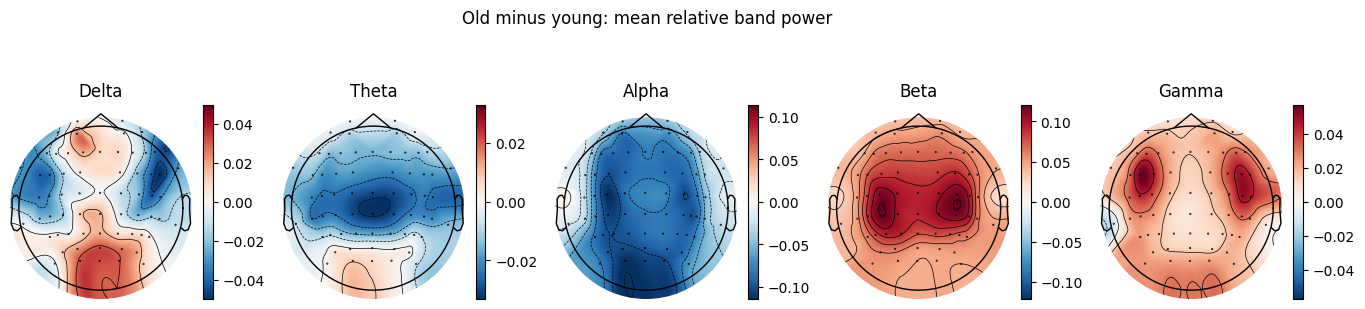

In [14]:
"""
Scalp maps of the difference in mean relative band power between the
old and young groups (old minus young).
"""

is_old = features_df["age_group"] == "old"

fig, axes = plt.subplots(1, len(FREQUENCY_BANDS), figsize=(17, 3.6))
for ax, band in zip(axes, FREQUENCY_BANDS):
    columns = [f"{ch}_{band}" for ch in example_epochs.ch_names]
    difference = (features_df.loc[is_old, columns].mean()
                  - features_df.loc[~is_old, columns].mean()).values
    limit = np.abs(difference).max()
    im, _ = mne.viz.plot_topomap(difference, example_epochs.info, axes=ax, show=False,
                                 cmap="RdBu_r", vlim=(-limit, limit))
    ax.set_title(band.capitalize())
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.suptitle("Old minus young: mean relative band power", y=1.03)
fig.savefig(f"{FIGURES_DIR}/03_group_difference_topomaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 14 — Retrieve the Feature Matrix and Figures for Local Use

`spectral_features.csv` is this notebook's primary output and the complete input to Notebook 04. It is downloaded to the local machine, together with this notebook's figures, since files on the Colab VM's disk are lost when the session ends.


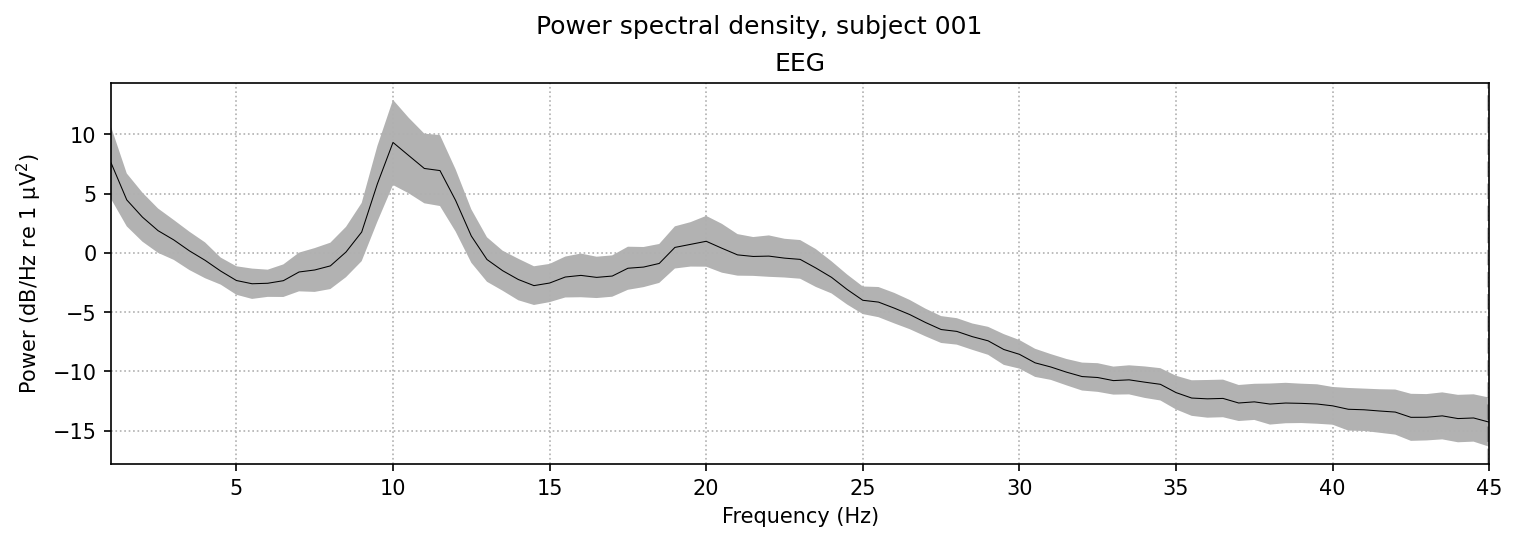


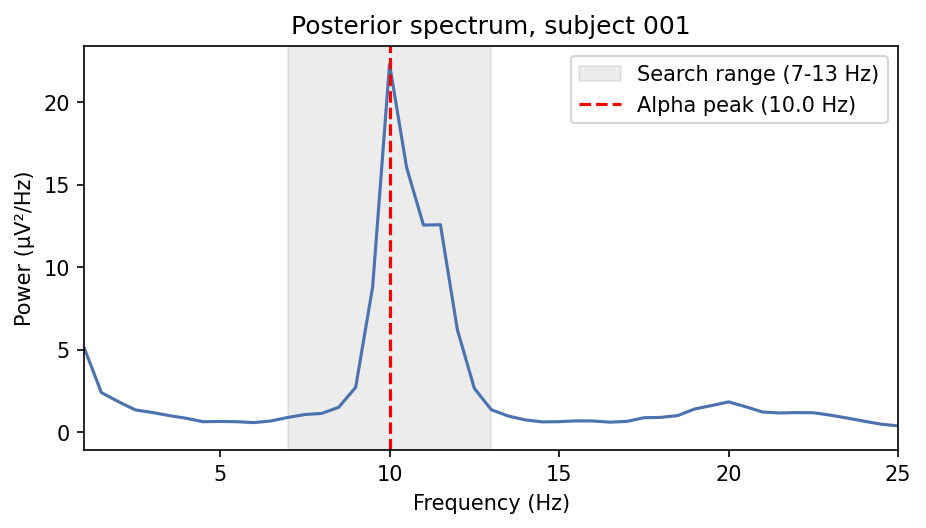


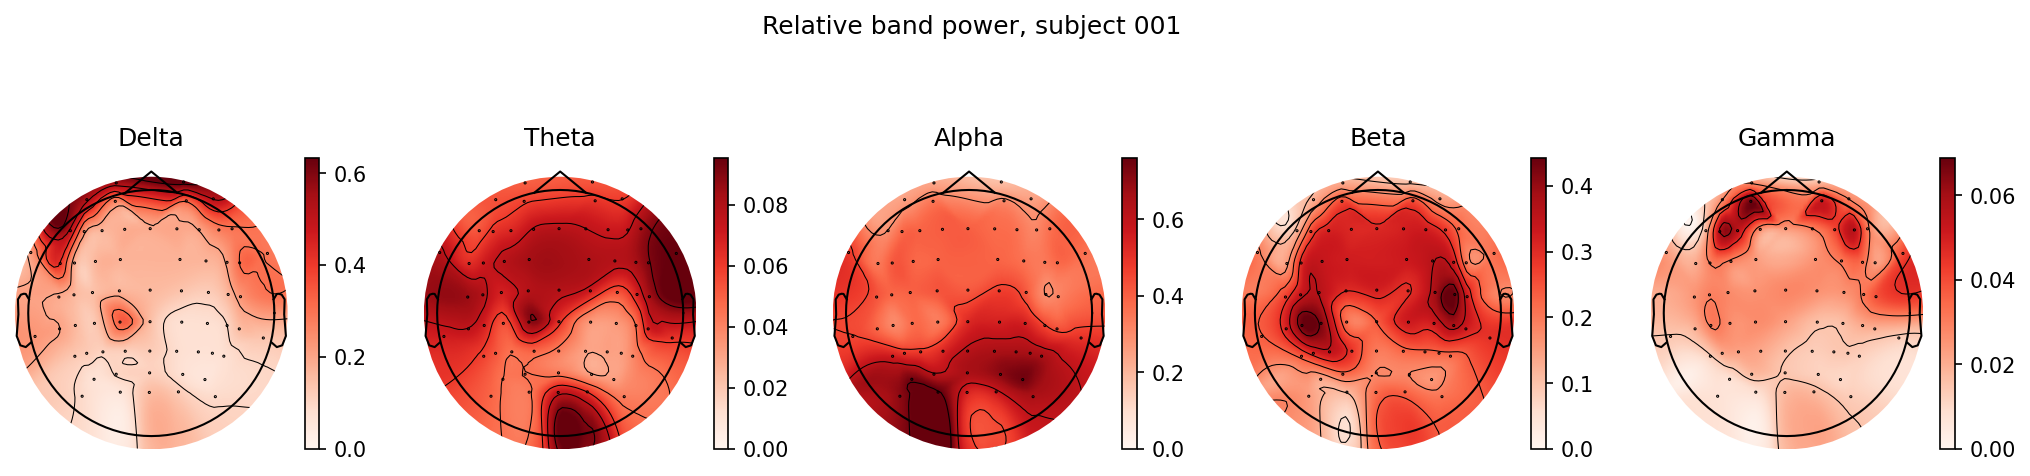


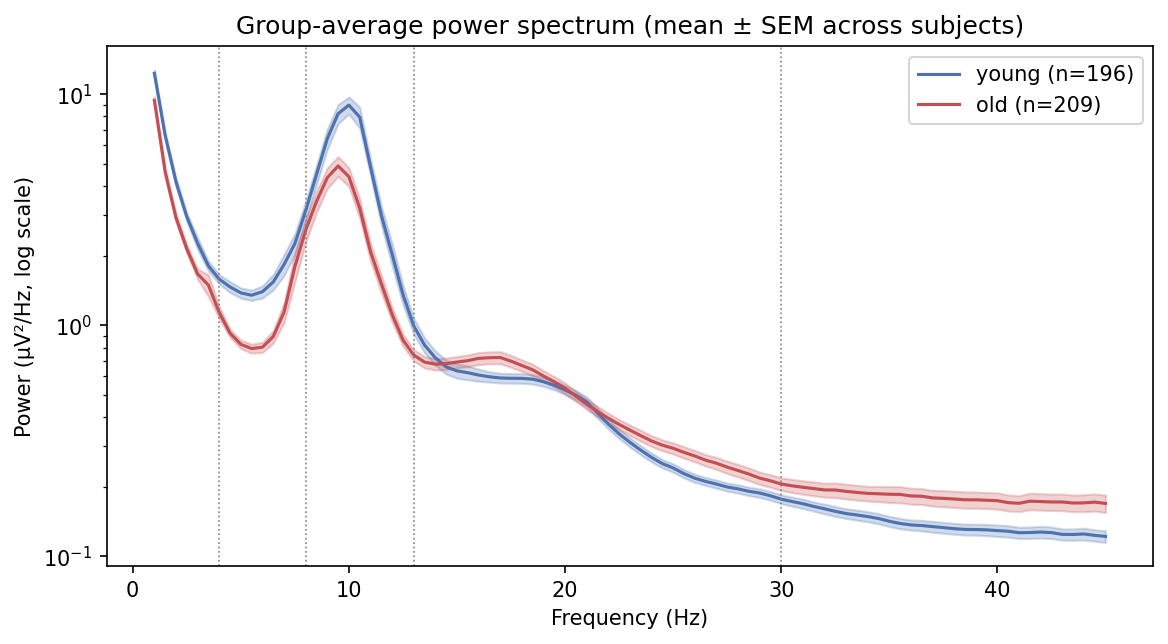


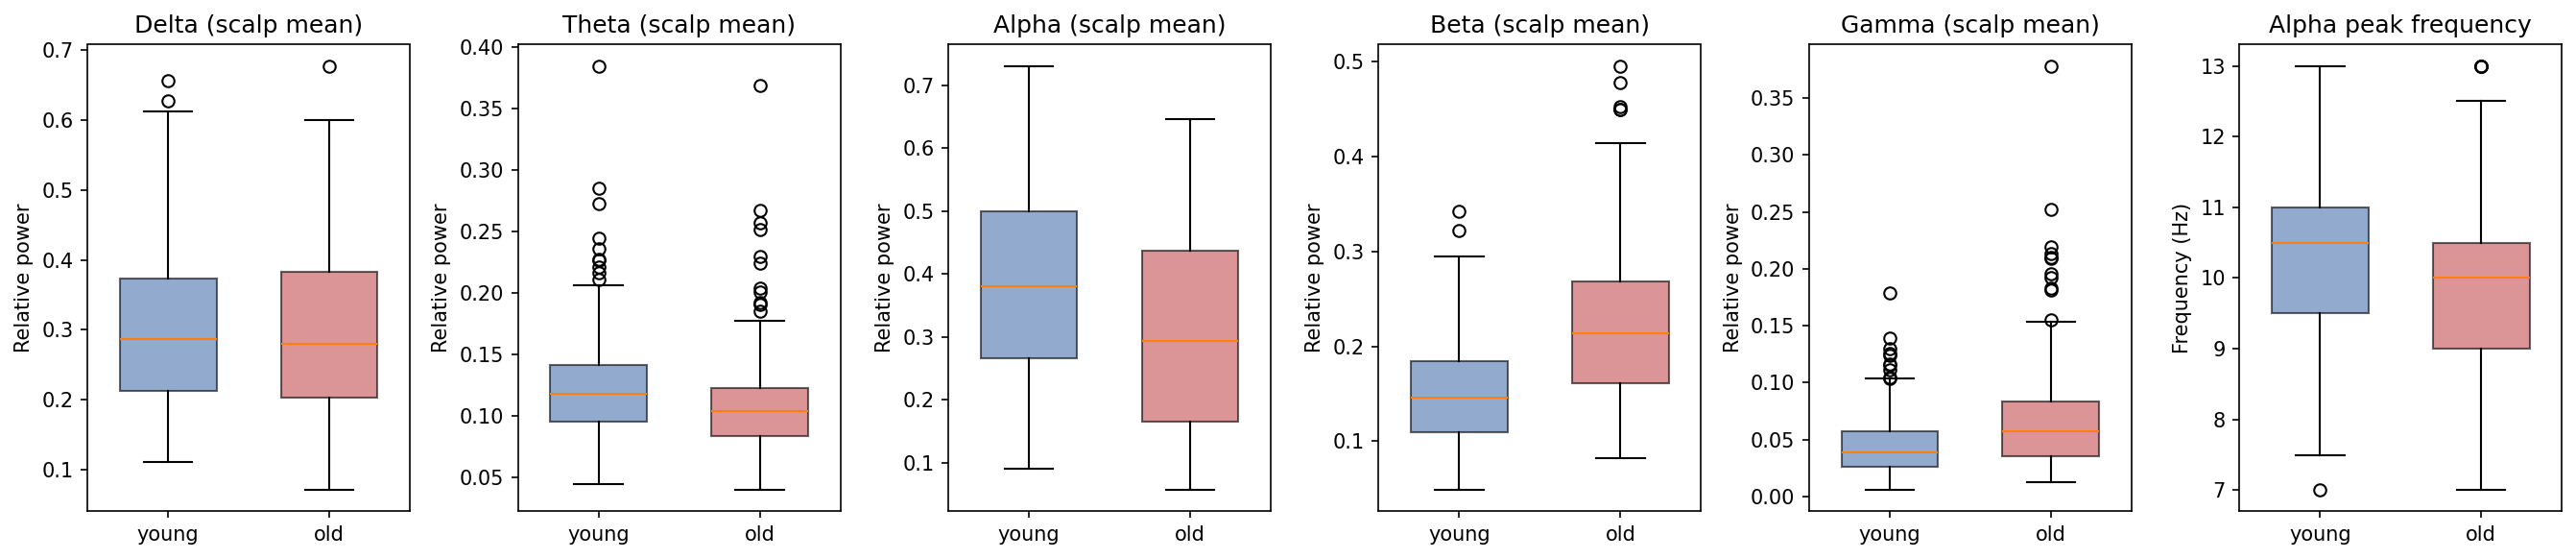


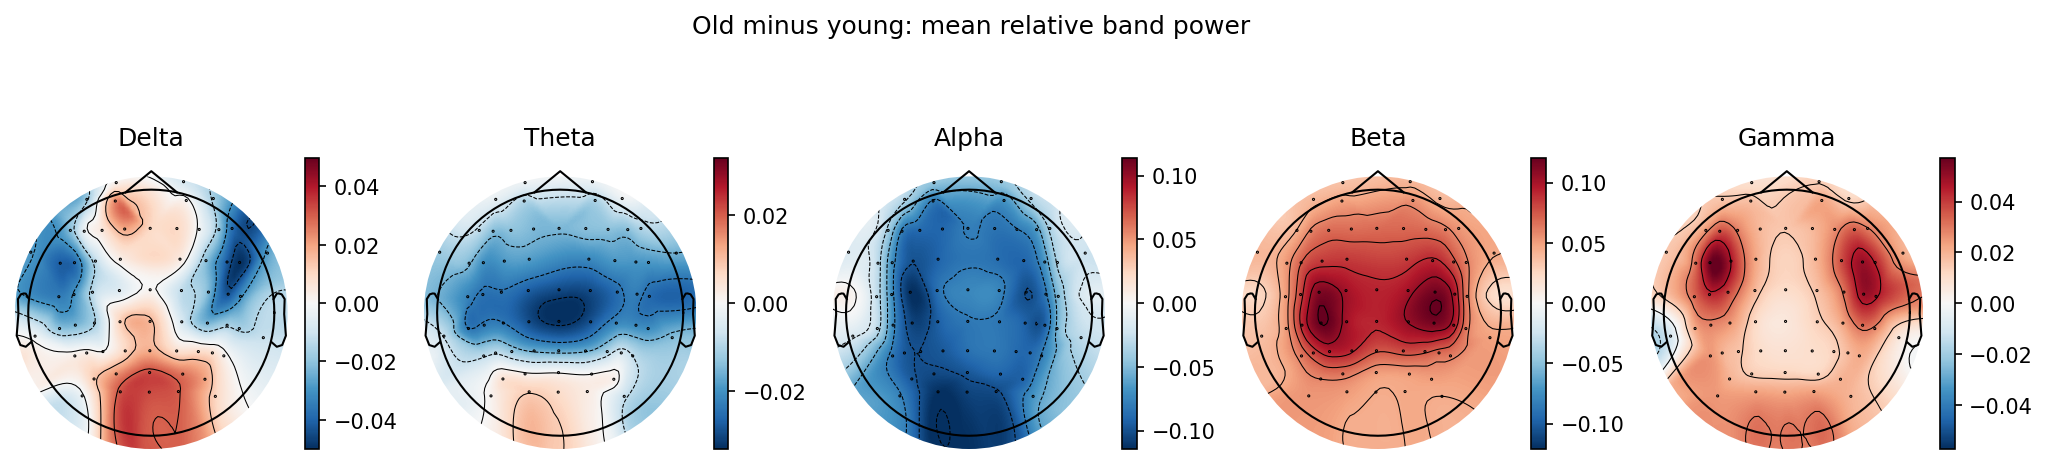

In [15]:
"""
Generate browser download links for this notebook's outputs.
"""

import base64
import mimetypes
from IPython.display import HTML, display


def download_link(filepath):
    filename = filepath.split("/")[-1]
    mime_type, _ = mimetypes.guess_type(filepath)
    mime_type = mime_type or "application/octet-stream"
    with open(filepath, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    return HTML(f'<a download="{filename}" href="data:{mime_type};base64,{b64}">Download {filename}</a>')


for path in [
    features_path,
    f"{FIGURES_DIR}/03_example_psd.png",
    f"{FIGURES_DIR}/03_example_alpha_peak.png",
    f"{FIGURES_DIR}/03_example_band_topomaps.png",
    f"{FIGURES_DIR}/03_group_spectra.png",
    f"{FIGURES_DIR}/03_group_band_power.png",
    f"{FIGURES_DIR}/03_group_difference_topomaps.png",
]:
    display(download_link(path))

## Summary

Subjects with fewer than 10 artifact-free epochs were excluded, and for every remaining subject the power spectral density was estimated with Welch's method (2-second windows, 50% overlap, 0.5 Hz resolution). Relative power was computed in five non-overlapping frequency bands at all 64 electrodes, and the individual alpha peak frequency was estimated from posterior electrodes, giving 321 features per subject. The feature matrix was saved as `spectral_features.csv`, without subject age, to prevent data leakage. Descriptive comparisons of group spectra, band power and scalp distributions provide a first look at age-related differences.

The next notebook (`04_gradient_boosting_classifier.ipynb`) trains and evaluates a gradient boosting classifier on this feature matrix using cross-validation, and runs locally, since it requires no further downloads.